In [1]:
!git clone https://github.com/mohammedumairuddin/EEEM073-AI-Sustainability-coursework.git

Cloning into 'EEEM073-AI-Sustainability-coursework'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 189 (delta 10), reused 2 (delta 2), pack-reused 151 (from 2)
Receiving objects: 100% (189/189), 2.89 MiB | 7.26 MiB/s, done.
Resolving deltas: 100% (84/84), done.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Updated the path to load 'crop_production.csv' from the cloned repository.
df = pd.read_csv("EEEM073-AI-Sustainability-coursework/datasets/crop_production.csv")

In [3]:
!ls

EEEM073-AI-Sustainability-coursework  sample_data


In [4]:
cd EEEM073-AI-Sustainability-coursework/

/content/EEEM073-AI-Sustainability-coursework


In [5]:
!ls

datasets  models  notebooks  README.md	requirements.txt  results


In [6]:
%cd datasets

/content/EEEM073-AI-Sustainability-coursework/datasets


In [7]:
!ls

crop_production.csv


In [8]:
#dataset overview
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


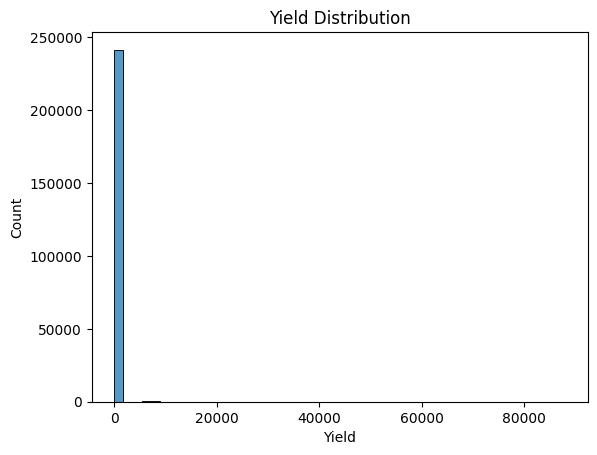

In [9]:
df["Yield"] = df["Production"] / df["Area"]
sns.histplot(df["Yield"], bins=50)
plt.title("Yield Distribution")
plt.show()

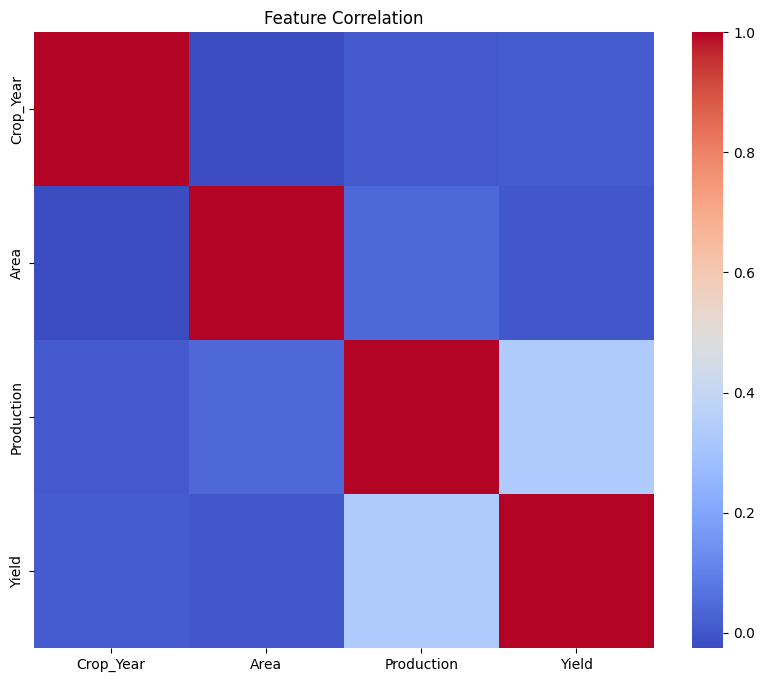

In [10]:
#understanding correlation through heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

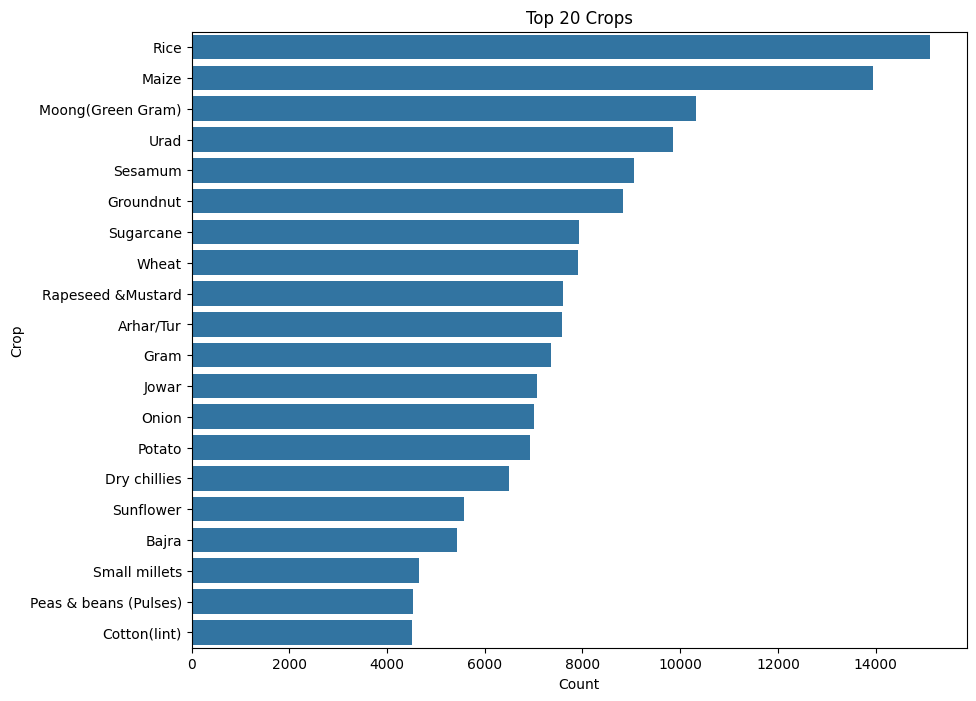

In [11]:
top_crops = df['Crop'].value_counts().nlargest(20)

plt.figure(figsize=(10,8))
sns.barplot(x=top_crops.values, y=top_crops.index)

plt.title("Top 20 Crops")
plt.xlabel("Count")
plt.ylabel("Crop")
plt.show()

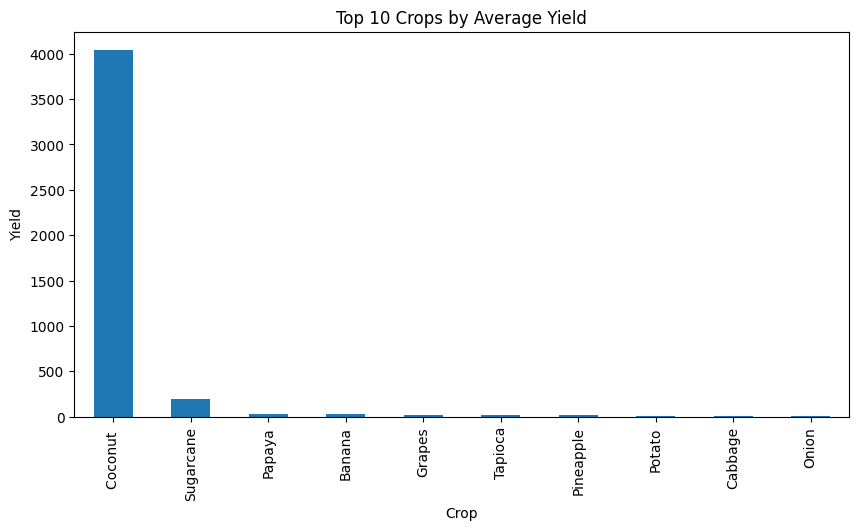

In [12]:


# Calculate average yield per crop
crop_yield = df.groupby("Crop")["Yield"].mean().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,5))
crop_yield.plot(kind="bar")
plt.title("Top 10 Crops by Average Yield")
plt.ylabel("Yield")

# Save for report
plt.savefig("../results/plots/top_crops_yield.png", dpi=300)

plt.show()

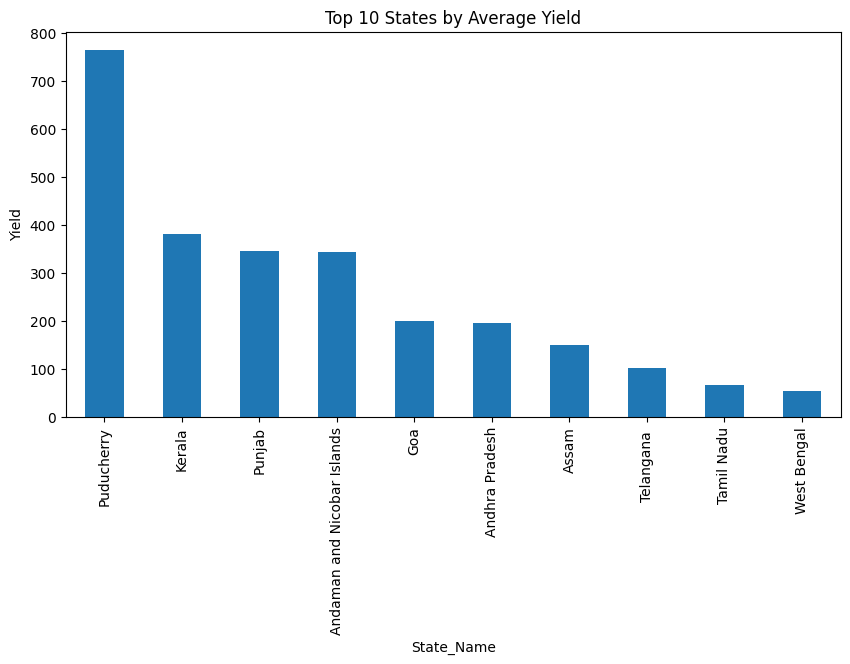

In [13]:


state_yield = df.groupby("State_Name")["Yield"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
state_yield.plot(kind="bar")
plt.title("Top 10 States by Average Yield")
plt.ylabel("Yield")

plt.savefig("../results/plots/state_yield.png", dpi=300)

plt.show()

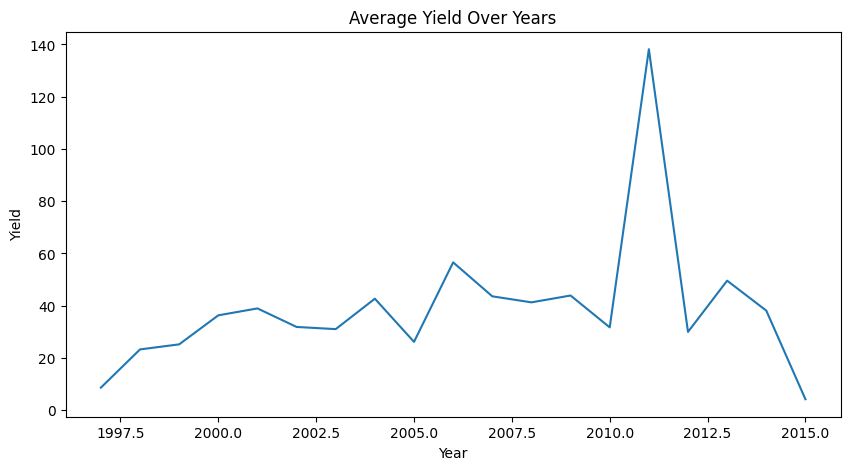

In [14]:


year_trend = df.groupby("Crop_Year")["Yield"].mean()

plt.figure(figsize=(10,5))
year_trend.plot()

plt.title("Average Yield Over Years")
plt.xlabel("Year")
plt.ylabel("Yield")

plt.savefig("../results/plots/yield_trend.png", dpi=300)

plt.show()

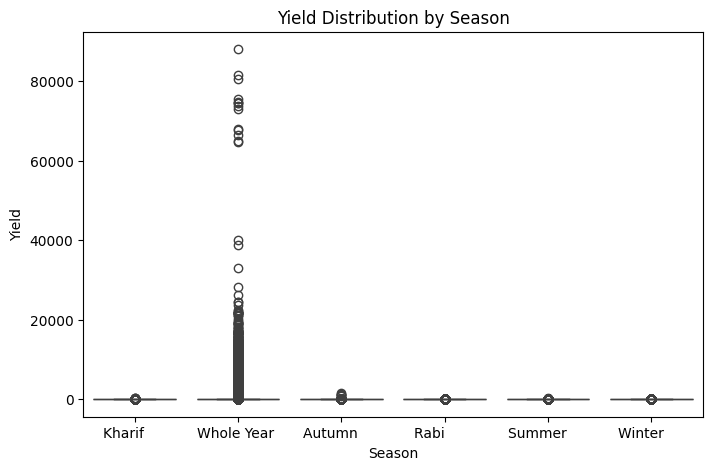

In [15]:


import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x="Season", y="Yield", data=df)

plt.title("Yield Distribution by Season")

plt.savefig("../results/plots/season_yield.png", dpi=300)

plt.show()

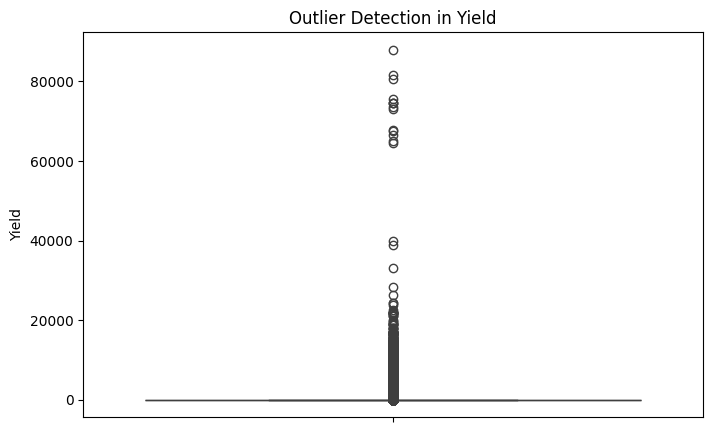

In [16]:


plt.figure(figsize=(8,5))
sns.boxplot(y=df["Yield"])

plt.title("Outlier Detection in Yield")

plt.savefig("../results/plots/yield_outliers.png", dpi=300)

plt.show()

Extreme values were analysed to ensure model robustness.



In [24]:
plt.savefig("../results/plots/filename.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [25]:
import shutil

shutil.make_archive("results_backup", 'zip', "../results")

'/content/EEEM073-AI-Sustainability-coursework/datasets/results_backup.zip'

In [26]:
from google.colab import files

files.download("results_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>